***Name1: Adwitiya Argha Priyadarshini Boruah***

***Matriculation No.1: 7070291***

***Email1: adbo00002@stud.uni-saarland.de***



**Name2: Md Mobashir Rahman**

***Matriculation No. 2: 7059086***

***Email2: mdra00001@stud.uni-saarland.de***











**Exercise 3.2: Matrix Balancing**

**a.**

The code loads a processed Micro-C dataset in .mcool format containing multi-resolution chromatin contact maps. The working directory is set to the location of the dataset, and the 1 Mb resolution is selected using the cooler interface. The available chromosomes in the dataset are listed to confirm successful loading. The genomic bins corresponding to chromosome 2 are then identified, and the appropriate row and column ranges are extracted from the genome-wide matrix. This produces the raw, unbalanced chromosome 2 contact matrix at 1 Mb resolution, which will be used for subsequent matrix-balancing steps.


In [2]:
import os
import cooler

#  Setting the working directory where the .mcool file is located

os.chdir("/Users/adwitiyaarghapb/Downloads")

#  Loading the Micro-C dataset at 1 Mb resolution. The file "4DNFI9GMP2J8.mcool" must be in the working folder. "::resolutions/1000000" selects the 1 Mb binning.
cooler_file = "4DNFI9GMP2J8.mcool"
resolution = 1000000   # 1 Mb bins

cool_obj = cooler.Cooler(f"{cooler_file}::resolutions/{resolution}")

# Printing the  available chromosomes in the dataset
print("Available chromosomes in the dataset:")
print(cool_obj.chromnames)

# 3. Extracting the contact matrix for chromosome 2 only. Each chromosome corresponds to a range of rows/columns n the full genome-wide Hi-C matrix.
chrom_name = "chr2"

# Fetching the bin table (rows in the matrix) that correspond to chr2

chr2_bins = cool_obj.bins().fetch(chrom_name)

# Determining matrix slice indices for chr2

start_index = chr2_bins.index[0]
end_index   = chr2_bins.index[-1] + 1   # Python slicing is exclusive at the end

# Extracting the raw (unbalanced) contact matrix for chr2
chr2_matrix = cool_obj.matrix(balance=False)[start_index:end_index,  start_index:end_index]

# Printing the matrix shape (should be ~240x240 for 1Mb resolution)
print(f"\nChr2 contact matrix loaded. Shape: {chr2_matrix.shape}")


Available chromosomes in the dataset:
['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22', 'chrX', 'chrY']

Chr2 contact matrix loaded. Shape: (243, 243)


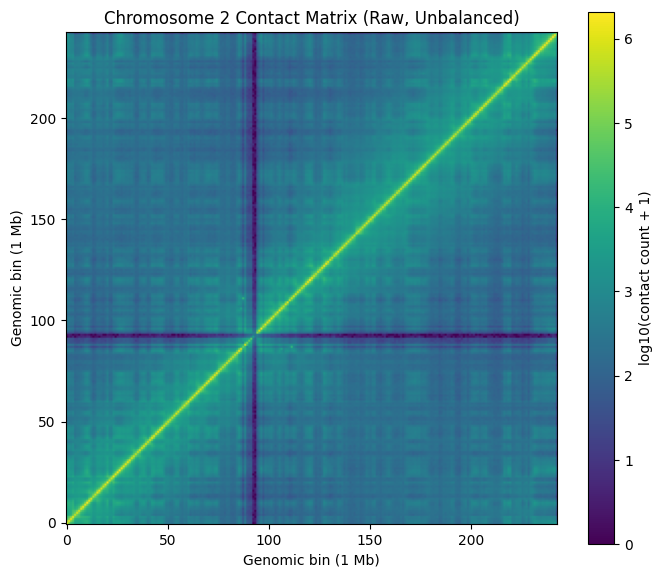

In [3]:
import numpy as np
import matplotlib.pyplot as plt

#The matrix 'chr2_matrix' is already loaded from part (a)
#Now we prepare it for plotting with a log color scale.


#Avoiding the  log(0) by adding a small constant
matrix_log = np.log10(chr2_matrix + 1)

#Plotting the heatmap (prior to bias removal)


plt.figure(figsize=(7, 6))
plt.imshow(matrix_log, cmap="viridis", origin="lower")
plt.colorbar(label="log10(contact count + 1)")
plt.title("Chromosome 2 Contact Matrix (Raw, Unbalanced)")
plt.xlabel("Genomic bin (1 Mb)")
plt.ylabel("Genomic bin (1 Mb)")
plt.tight_layout()
plt.show()


**b.**

A raw contact heatmap of chromosome 2 is plotted before applying any bias correction. The interaction counts span several orders of magnitude, so a base-10 logarithmic transformation is used to reveal both strong and weak interaction patterns. The viridis colormap provides a perceptually uniform scale, improving the visibility of structural features. The strong diagonal reflects frequent contacts between nearby genomic bins, while variations in intensity across the matrix indicate regional differences in chromatin interaction frequency. This visualisation serves as a baseline for assessing the effect of subsequent matrix-balancing steps.

**c.**

Vanilla coverage normalisation was applied to the chromosome 2 contact matrix to correct for unequal sequencing depth across genomic bins. The total interaction count for each bin was computed, and these coverage values were used to scale the raw matrix by dividing each entry by the product of the corresponding row and column coverages. A logarithmic transformation was then applied to enhance visibility of the normalised interaction pattern, and the resulting matrix was visualised using a perceptually uniform colormap.


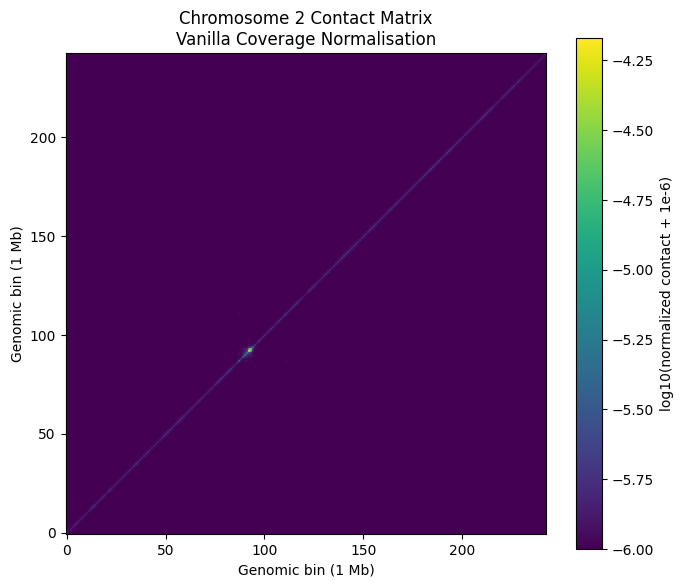

In [4]:
#Computing the bin coverage for chromosome 2
#coverage_i = sum of all contacts involving bin i
bin_coverage = np.sum(chr2_matrix, axis=1)  # vector of length N

#Replacing zero-coverage bins, if there is any, to avoid division-by-zero errors
safe_coverage = np.where(
    bin_coverage == 0,
    np.min(bin_coverage[np.nonzero(bin_coverage)]),
    bin_coverage
)

#Applying the Vanilla Coverage normalisation:
#normalized[i,j] = raw[i,j] / (coverage[i] * coverage[j])

vanilla_normalized = chr2_matrix / (safe_coverage[:, None] * safe_coverage[None, :])

#Log-transform to improve visibility when plotting
log_normalized_matrix = np.log10(vanilla_normalized + 1e-6)

#Plotting the Vanilla Coverage–balanced matrix
plt.figure(figsize=(7, 6))
plt.imshow(log_normalized_matrix, cmap="viridis", origin="lower")
plt.colorbar(label="log10(normalized contact + 1e-6)")
plt.title("Chromosome 2 Contact Matrix\nVanilla Coverage Normalisation")
plt.xlabel("Genomic bin (1 Mb)")
plt.ylabel("Genomic bin (1 Mb)")
plt.tight_layout()
plt.show()


Vanilla coverage normalisation reduces broad differences in interaction intensity by correcting for variation in bin coverage. After normalisation, most contact values become extremely small because highly covered bins are strongly downscaled. As a result, the heatmap shows a mostly uniform low-intensity background, with only a few regions retaining detectable signal. This pattern reflects the expected effect of Vanilla Coverage, the global biases are removed, but much of the structural contrast is compressed, leaving only the strongest interactions visible.

**d.**

The Iterative Correction and Eigenvector decomposition (ICE) algorithm was used to balance the chromosome 2 contact matrix. A bias vector initialised to ones was repeatedly updated by computing each bin’s total interaction count and deriving a correction factor from its inverse. The matrix was multiplicatively adjusted using these bias corrections, then rescaled to keep the total contact sum constant. These steps were iterated until the change in the bias vector fell below
10^{-6}, indicating convergence.

Converged after 3 iterations.


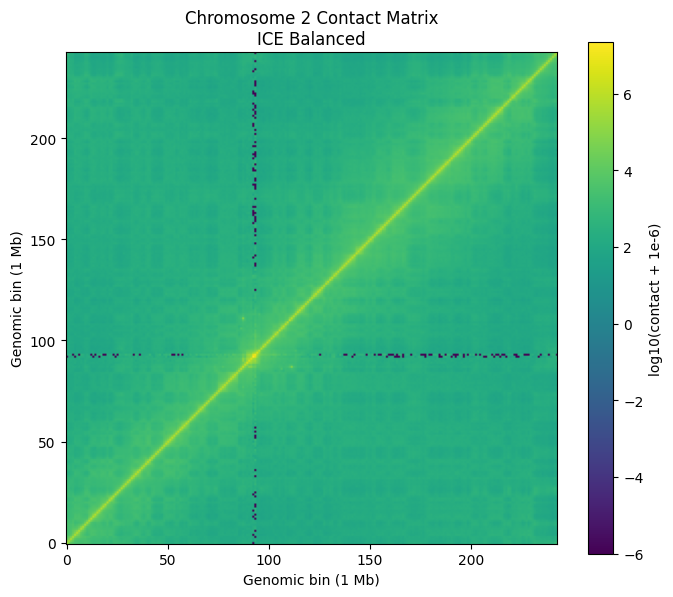

In [5]:
# Starting matrix (from part a): chr2_matrix
# Converting to float to avoid integer division issues

matrix_current = chr2_matrix.astype(float)


#1. Initialising bias vector b^(0) = all ones

num_bins = matrix_current.shape[0]
bias_vector = np.ones(num_bins)


#2.  Global contact sum T (remains constant)
global_total = np.sum(matrix_current)


# Iteration parameters

tolerance = 1e-6
max_iterations = 200
iteration = 0

while iteration < max_iterations:


    #3. Computing the per-bin coverage S_i

    coverage = np.sum(matrix_current, axis=1)

    #4. Computing the delta bias

    delta_bias = 1.0 / coverage
    # Replace zeros to avoid division problems
    delta_bias[np.isinf(delta_bias)] = 1.0


    #5. Updating the matrix

    matrix_next = matrix_current * (delta_bias[:, None] * delta_bias[None, :])

    #6. Updating the total bias vector

    bias_new = bias_vector * delta_bias

    #7.  Rescaling the matrix to preserve global total T

    current_sum = np.sum(matrix_next)
    matrix_next = matrix_next * (global_total / current_sum)

    #8.  Checking the convergence

    if np.max(np.abs(bias_new - bias_vector)) < tolerance:
        print(f"Converged after {iteration+1} iterations.")
        break

    # Updating for next iteration
    bias_vector = bias_new
    matrix_current = matrix_next
    iteration += 1

# Final ICE-balanced matrix
ice_matrix = matrix_next

# Visualisation of ICE-balanced matrix

plt.figure(figsize=(7, 6))
plt.imshow(np.log10(ice_matrix + 1e-6), cmap="viridis", origin="lower")
plt.colorbar(label="log10(contact + 1e-6)")
plt.title("Chromosome 2 Contact Matrix\nICE Balanced")
plt.xlabel("Genomic bin (1 Mb)")
plt.ylabel("Genomic bin (1 Mb)")
plt.tight_layout()
plt.show()

ICE balancing equalises the interaction coverage of all genomic bins, removing technical biases such as mappability differences or sequencing depth variations. After correction, the matrix shows a more uniform background and clearer structural patterns along the diagonal, while low-coverage bins remain visible as dark streaks. The rapid convergence within a few iterations reflects stable and well-behaved contact data at 1 Mb resolution.

**e.**

The ICE procedure reached convergence after 3 iterations, indicating that the bias vector stabilised rapidly and the per-bin interaction totals became uniform. Vanilla coverage does not iterate and therefore has no convergence behaviour, it applies only a single scaling step based on bin coverage.

The two approaches produce noticeably different results. Vanilla coverage removes global coverage differences but strongly compresses the dynamic range, leaving only a few high-intensity contacts visible. ICE, by contrast, repeatedly corrects biases until the interaction totals across bins match, which yields a more balanced matrix while preserving large-scale chromatin structure. As a result, ICE provides a more informative and biologically interpretable normalisation than the simpler Vanilla method.